
Mg_R1s(r) =
+49.5155 * exp(-17.0241 r)
+27.5710 * exp(-10.0727 r)
+189.1837 * r * exp(-14.6751 r)
+0.1571 * r * exp(-5.1514 r)
+0.0146 * r * exp(-3.4870 r)
-0.0016 * r * exp(-2.5249 r)
-41.2388 * r^2 * exp(-29.9018 r)
-0.0002 * r^2 * exp(-1.7568 r)
-0.0000 * r^2 * exp(-1.1659 r)
+0.0000 * r^2 * exp(-0.8244 r)

Mg_R2s(r) =
+8.3258 * exp(-17.0241 r)
-28.6104 * exp(-10.0727 r)
+53.2584 * r * exp(-14.6751 r)
+24.7008 * r * exp(-5.1514 r)
+18.2643 * r * exp(-3.4870 r)
+0.6836 * r * exp(-2.5249 r)
+17.4448 * r^2 * exp(-29.9018 r)
-0.0036 * r^2 * exp(-1.7568 r)
+0.0002 * r^2 * exp(-1.1659 r)
-0.0000 * r^2 * exp(-0.8244 r)

Mg_R3s(r) =
+2.2552 * exp(-17.0241 r)
-6.1651 * exp(-10.0727 r)
+14.0846 * r * exp(-14.6751 r)
+5.3823 * r * exp(-5.1514 r)
+2.9096 * r * exp(-3.4870 r)
+0.9693 * r * exp(-2.5249 r)
+0.6164 * r^2 * exp(-29.9018 r)
-0.7054 * r^2 * exp(-1.7568 r)
-0.3570 * r^2 * exp(-1.1659 r)
-0.0813 * r^2 * exp(-0.8244 r)

Mg_R2p(r) =
+4.1358 * r * exp(-14.9021 r)
+24.5305 * r * exp(-6.807

/tmp/ipykernel_20308/3563713249.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00       6.680452e-02       3.418725e-01       1.579168e+00   
1       0.05       6.680056e-02       3.414726e-01       1.541891e+00   
2       0.10       6.678867e-02       3.402762e-01       1.435899e+00   
3       0.15       6.676887e-02       3.382931e-01       1.277041e+00   
4       0.20       6.674116e-02       3.355395e-01       1.086890e+00   
...      ...                ...                ...                ...   
1996   99.80       1.181468e-07       8.236780e-09       3.072540e-10   
1997   99.85       1.176213e-07       8.200031e-09       3.058835e-10   
1998   99.90       1.170976e-07       8.163410e-09       3.045177e-10   
1999   99.95       1.165758e-07       8.126915e-09       3.031566e-10   
2000  100.00       1.160557e-07       8.090546e-09       3.018002e-10   

      J_2p_one_electron       J_1s(2)       J_2s(2)       J_2p(6)  \
0          1.917835e-01  1.336090e-01  6.837451e-01  1

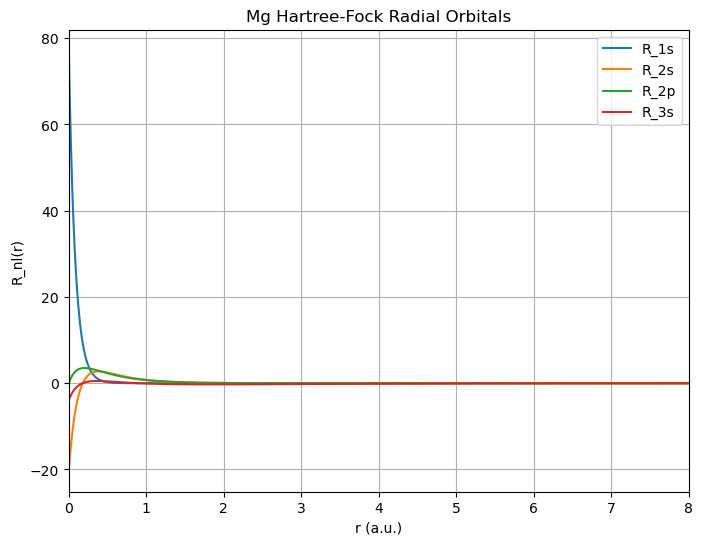

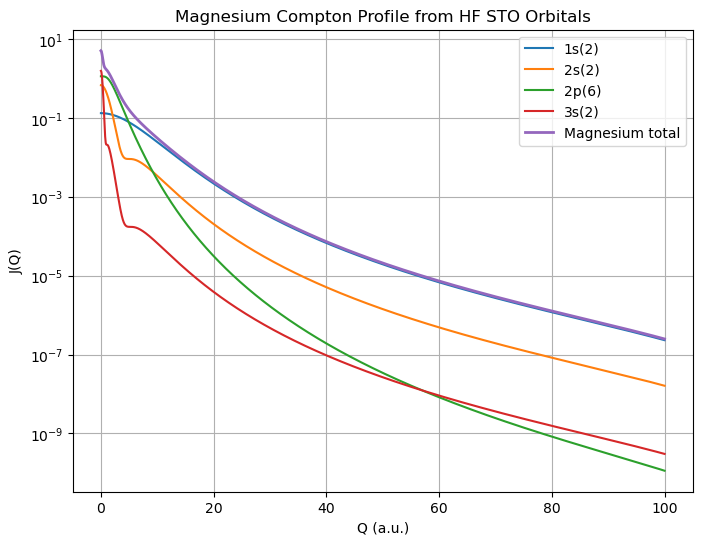

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Magnesium Hartree-Fock STO data
# Mg: 1s(2) 2s(2) 2p(6) 3s(2)
# Format: (n_j, Z_j, C_j)
# =====================================================

magnesium_1s = [
    (1, 17.0241,  0.352464),
    (1, 10.0727,  0.431225),
    (2, 14.6751,  0.198592),
    (2,  5.1514,  0.002259),
    (2,  3.4870,  0.000556),
    (2,  2.5249, -0.000136),
    (3, 29.9018, -0.000669),
    (3,  1.7568, -0.000056),
    (3,  1.1659, -0.000033),
    (3,  0.8244,  0.000011),
]

magnesium_2s = [
    (1, 17.0241,  0.059265),
    (1, 10.0727, -0.447481),
    (2, 14.6751,  0.055907),
    (2,  5.1514,  0.355163),
    (2,  3.4870,  0.696633),
    (2,  2.5249,  0.058440),
    (3, 29.9018,  0.000283),
    (3,  1.7568, -0.001173),
    (3,  1.1659,  0.000277),
    (3,  0.8244, -0.000059),
]

magnesium_3s = [
    (1, 17.0241,  0.016053),
    (1, 10.0727, -0.096426),
    (2, 14.6751,  0.014785),
    (2,  5.1514,  0.077390),
    (2,  3.4870,  0.110979),
    (2,  2.5249,  0.082870),
    (3, 29.9018,  0.000010),
    (3,  1.7568, -0.232777),
    (3,  1.1659, -0.494745),
    (3,  0.8244, -0.378869),
]

magnesium_2p = [
    (2, 14.9021, 0.004178),
    (2,  6.8076, 0.175692),
    (2,  4.1426, 0.420054),
    (2,  2.7152, 0.456246),
    (2,  1.4623, 0.012155),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build nitrogen radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, magnesium_1s)
R2s = R_nl(r, magnesium_2s)
R3s = R_nl(r, magnesium_3s)
R2p = R_nl(r, magnesium_2p)

print_R_formula(magnesium_1s, "Mg_R1s")
print_R_formula(magnesium_2s, "Mg_R2s")
print_R_formula(magnesium_3s, "Mg_R3s")
print_R_formula(magnesium_2p, "Mg_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

# Nitrogen has 1s(2) 2s(2) 2p(3)
J_total = 2*J_1s + 2*J_2s + 2*J_3s + 6*J_2p
# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_total_Magnesium": J_total
})
print(table)
table.to_csv("Magnesium_HF_Compton_profile.csv", index=False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Mg Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, J_3s, label="3s(2)")
plt.plot(Q, J_total, label="Magnesium total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Magnesium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()